# Shea Homes Customer Review Analysis
### Notebook: `04_advanced_nlp`

> Run `01_setup_and_summary_stats.ipynb` first, or execute the setup cell below.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
from scipy import stats
import re
import warnings
warnings.filterwarnings("ignore")

# nlp tools
import nltk
nltk.download("vader_lexicon", quiet=True)
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from textblob import TextBlob
from wordcloud import WordCloud
import spacy

#ml
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.pipeline import Pipeline

# visual style
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
SHEA_BLUE = "#1a5276"
SHEA_GOLD = "#d4a843"
SHEA_PALETTE = ["#c0392b", "#e67e22", "#f1c40f", "#27ae60", "#1a5276"]

# keep apostrophes so contractions like "don't" stay as one token
TOKEN_PATTERN = r"(?u)\b\w[\w']+\b"

In [3]:
# load the dataset
df = pd.read_csv("../builder_reviews/shea-homes_reviews.csv", encoding="utf-8-sig")
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# derived columns
df["word_count"] = df["review_text"].apply(lambda x: len(str(x).split()))
df["char_count"] = df["review_text"].apply(lambda x: len(str(x)))
df["state"] = df["location"].str.extract(r",\s*([A-Z]{2})$")
df["year"] = df["date"].dt.year
df["year_month"] = df["date"].dt.to_period("M")
df["quarter"] = df["date"].dt.to_period("Q")

print(f"{len(df):,} reviews")
print(f"Date range: {df['date'].min().strftime('%B %Y')} to {df['date'].max().strftime('%B %Y')}")
df.head(3)

2,052 reviews
Date range: September 2020 to April 2026


,title,reviewer_name,verified_homebuyer,date,location,review_text,total_score,quality,trustworthiness,value,responsiveness,word_count,char_count,state,year,year_month,quarter
0,Good overall,Constance G.,Yes,2026-04-01,"OCALA, FL",A little overwhelming for me as a single elder...,5,5,5,5,5,86,434,FL,2026,2026-04,2026Q2
1,"Excellent, knowledgeable and responsive",Emily V.,Yes,2026-03-31,"Littleton, CO",Our experience exceeded our expectations. The ...,5,5,5,5,5,32,218,CO,2026,2026-03,2026Q1
2,Overall great experience!,Lynn S.,Yes,2026-03-26,"Kuna, ID",This is our second Shea home! Our whole proces...,5,5,5,5,5,83,516,ID,2026,2026-03,2026Q1


In [4]:
# ── Prerequisites: compute sentiment columns ──
# (These are normally created in notebook 03_sentiment_analysis)
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from textblob import TextBlob

sia = SentimentIntensityAnalyzer()
scores = df["review_text"].apply(lambda x: sia.polarity_scores(str(x)))
df["vader_compound"] = scores.apply(lambda x: x["compound"])
df["vader_pos"] = scores.apply(lambda x: x["pos"])
df["vader_neg"] = scores.apply(lambda x: x["neg"])
df["vader_neu"] = scores.apply(lambda x: x["neu"])
df["vader_label"] = df["vader_compound"].apply(
    lambda x: "Positive" if x >= 0.05 else ("Negative" if x <= -0.05 else "Neutral"))
df["textblob_polarity"] = df["review_text"].apply(lambda x: TextBlob(str(x)).sentiment.polarity)
df["textblob_label"] = df["textblob_polarity"].apply(
    lambda x: "Positive" if x > 0.05 else ("Negative" if x < -0.05 else "Neutral"))

# stop words
from nltk.corpus import stopwords
stop_words = set(stopwords.words("english"))
stop_words.update(["home","shea","homes","new","would","one","us","also","get","got",
    "even","like","really","much","could","said","told","went","going","still",
    "back","made","make","well","since","every"])
print(f"Sentiment columns ready. {len(df)} reviews, VADER pos/neg/neu computed.")


Sentiment columns ready. 2052 reviews, VADER pos/neg/neu computed.


---
# Part 4: Advanced Sentiment Analysis

This section applies advanced natural language processing (NLP) techniques to find insights from customer reviews. Rather than only measuring whether reviews are positive or negative, these methods analyze the text to identify recurring themes, frequently discussed topics, and patterns in how customers describe their experiences.

The analysis also looks for which aspects of the homebuying experience customers mention most often, such as sales interactions, construction quality, or warranty service. By analyzing groups of words and phrases together, these techniques show more detailed patterns in customer feedback and help find the specific areas of the business that drive satisfaction or dissatisfaction.

---
# 4.1 Topic Discovery (LDA)

This section uses a technique called topic modeling to automatically identify the main subjects customers discuss in their reviews. The specific method used, Latent Dirichlet Allocation (LDA), analyzes patterns of words that frequently appear together across the dataset. Reviews that contain similar groups of words are grouped into a shared topic, allowing the model to discover common themes without being manually labeled in advance.

By applying this approach to all reviews, the model identifies the major themes in customer feedback, such as construction quality, the buying process, sales interactions, and post-purchase issues. This provides a structured overview of what customers talk about most often.

In [7]:
count_vec = CountVectorizer(
    max_features=2000,
    stop_words=list(stop_words),
    min_df=5,
    max_df=0.7,
    ngram_range=(1, 2),
    token_pattern=TOKEN_PATTERN,
)

doc_term_matrix = count_vec.fit_transform(df["review_text"].astype(str))
feature_names = count_vec.get_feature_names_out()

print(f"Text converted to numbers: {doc_term_matrix.shape[0]} reviews × {doc_term_matrix.shape[1]} unique terms")

Text converted to numbers: 2052 reviews × 2000 unique terms


In [8]:
# run LDA topic modeling 
N_TOPICS = 6

lda = LatentDirichletAllocation(
    n_components=N_TOPICS,
    random_state=42,
    max_iter=25,
    learning_method="online",
)
lda.fit(doc_term_matrix)

# assign human-readable labels based on the top words in each topic
print("=" * 70)
print("Topics")
print("=" * 70)

topic_keywords = []
for idx, topic in enumerate(lda.components_):
    top_words = [feature_names[i] for i in topic.argsort()[-12:][::-1]]
    topic_keywords.append(top_words)
    print(f"\n  Topic {idx + 1}: {', '.join(top_words[:8])}")
    print(f"           {', '.join(top_words[8:])}")

Topics

  Topic 1: process, experience, great, team, sales, build, design, buying
           warranty, responsive, helpful, building

  Topic 2: house, good, experience, love, quality, issues, issue, right
           overall, community, time, things

  Topic 3: quality, customer, service, customer service, price, construction, issues, vs
           poor, work, service rep, sales

  Topic 4: issues, house, work, paint, months, done, things, water
           door, many, several, closing

  Topic 5: list, experience, office, teams, zero, rep, better, sales office
           trilogy, never, punch, punch list

  Topic 6: buyer, issues, follow, manager, construction, sale, construction manager, beware
           good, time, sales, including


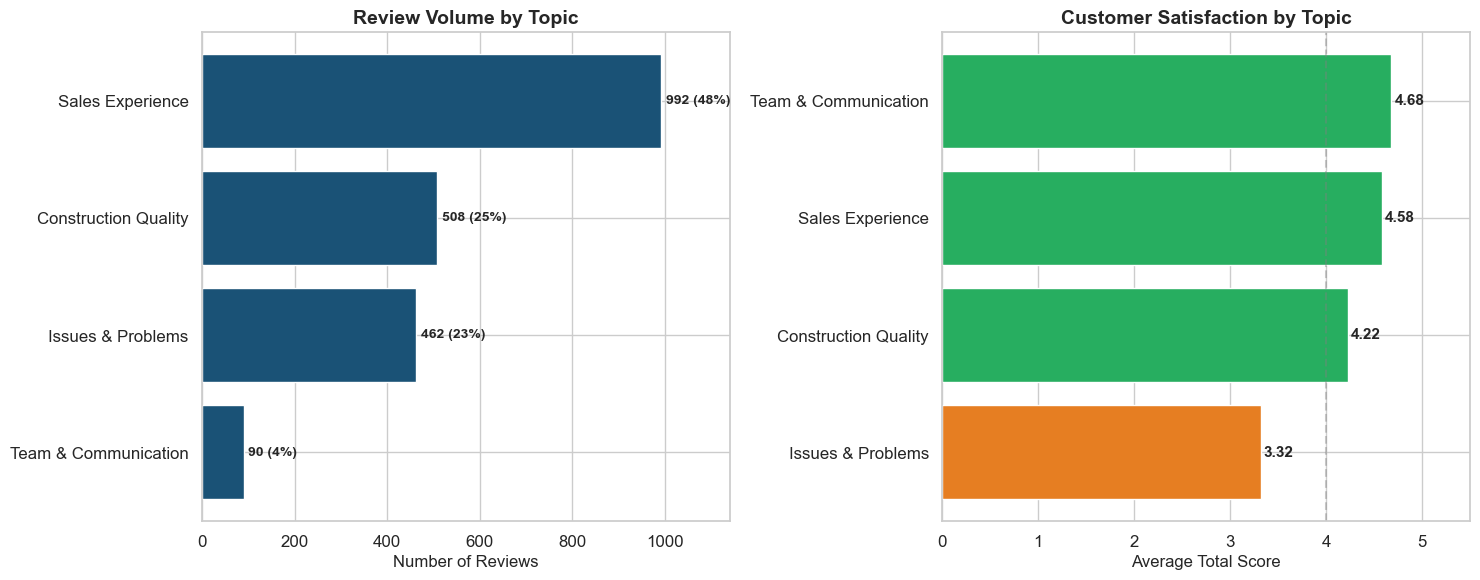

In [9]:
# assign each review its dominant topic
topic_distributions = lda.transform(doc_term_matrix)
df["dominant_topic"] = topic_distributions.argmax(axis=1) + 1  # 1-indexed
df["topic_confidence"] = topic_distributions.max(axis=1)

# let users define topic names after seeing the keywords above
# these are reasonable defaults based on typical Shea review content
TOPIC_NAMES = {}
for i in range(1, N_TOPICS + 1):
    TOPIC_NAMES[i] = f"Topic {i}"

# auto-label based on keyword content
label_hints = {
    "sales": "Sales Experience",
    "warranty": "Warranty & Post-Purchase",
    "quality": "Construction Quality",
    "community": "Community & Lifestyle",
    "process": "Buying Process",
    "team": "Team & Communication",
    "design": "Design & Features",
    "price": "Value & Pricing",
    "construction": "Construction Quality",
    "move": "Move-In Experience",
    "closing": "Closing Process",
    "issues": "Issues & Problems",
    "response": "Responsiveness",
}

for topic_num, keywords in enumerate(topic_keywords, 1):
    for keyword, label in label_hints.items():
        if any(keyword in kw for kw in keywords[:6]):
            TOPIC_NAMES[topic_num] = label
            break

df["topic_name"] = df["dominant_topic"].map(TOPIC_NAMES)

# visualize topic distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# left: topic frequency
topic_counts = df["topic_name"].value_counts()
axes[0].barh(topic_counts.index[::-1], topic_counts.values[::-1], color=SHEA_BLUE, edgecolor="white")
max_val = topic_counts.max()
axes[0].set_xlim(0, max_val * 1.15)
for i, (val, name) in enumerate(zip(topic_counts.values[::-1], topic_counts.index[::-1])):
    axes[0].text(val + 10, i, f"{val} ({val/len(df):.0%})", va="center", fontsize=10, fontweight="bold")
axes[0].set_xlabel("Number of Reviews", fontsize=12)
axes[0].set_title("Review Volume by Topic", fontsize=14, fontweight="bold")

# right: avg score by topic
topic_scores = df.groupby("topic_name")["total_score"].mean().sort_values()
colors = ["#27ae60" if v >= 4.0 else "#e67e22" if v >= 3.0 else "#c0392b" for v in topic_scores]
axes[1].barh(topic_scores.index, topic_scores.values, color=colors, edgecolor="white")
for i, (val, name) in enumerate(zip(topic_scores.values, topic_scores.index)):
    axes[1].text(val + 0.03, i, f"{val:.2f}", va="center", fontsize=11, fontweight="bold")
axes[1].set_xlim(0, 5.5)
axes[1].set_xlabel("Average Total Score", fontsize=12)
axes[1].set_title("Customer Satisfaction by Topic", fontsize=14, fontweight="bold")
axes[1].axvline(x=4.0, color="gray", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

The algorithm discovered 6 distinct topics without any guidance. Construction quality appears most frequently, representing the largest share of customer discussion. Topics related to the buying process and sales experience also appear often and tend to receive the highest satisfaction scores. In contrast, reviews grouped under issues and problems show noticeably lower satisfaction levels. This pattern suggests that while the sales and purchasing experience is generally well received, dissatisfaction is more commonly associated with construction defects or post-delivery service issues.


---
# 4.2 Aspect-Based Sentiment Analysis

Aspect-based sentiment analysis examines how customers feel about specific parts of the homebuying experience. Instead of assigning a single sentiment score to an entire review, this method identifies mentions of key business areas (sales, construction quality, warranty service, communication, design, and pricing) and measures sentiment for each one separately.

This approach is useful because customers often discuss multiple aspects within the same review. For example, a customer may write one sentence praising the sales team and another complaining about drywall cracks. Aspect-based sentiment analysis evaluates each of these mentions separately, scoring the sales interaction as positive and the construction issue as negative rather than averaging the entire review into a single score.

In [12]:
# define aspect keyword dictionaries
# if a review mentions these words, we know it's discussing that aspect
ASPECTS = {
    "Sales & Buying Process": [
        "sales", "buying", "purchase", "contract", "closing", "escrow",
        "realtor", "agent", "sales rep", "sales team", "deposit",
        "financing", "mortgage", "loan", "interest rate", "pre-approval",
    ],
    "Construction Quality": [
        "quality", "construction", "build", "built", "craftsmanship",
        "materials", "drywall", "paint", "flooring", "foundation",
        "plumbing", "electrical", "roof", "windows", "doors", "cabinets",
        "concrete", "cracks", "defects", "defect", "workmanship",
    ],
    "Communication & Responsiveness": [
        "communication", "responsive", "response", "respond", "answered",
        "call", "email", "phone", "update", "informed", "transparent",
        "kept us", "follow up", "follow-up", "reached out", "timely",
        "ignored", "never called", "no response", "ghosted",
    ],
    "Warranty & Post-Move": [
        "warranty", "repair", "fix", "fixed", "issue", "issues",
        "problem", "problems", "maintenance", "service request",
        "punch list", "walk-through", "walkthrough", "inspection",
        "one month", "30 day", "post-close", "after moving",
    ],
    "Design & Floor Plan": [
        "design", "floor plan", "layout", "floorplan", "model",
        "upgrade", "upgrades", "options", "features", "kitchen",
        "bathroom", "bedroom", "backyard", "garage", "space",
        "spacious", "open concept", "modern", "finishes", "countertop",
    ],
    "Value & Pricing": [
        "value", "price", "pricing", "cost", "expensive", "affordable",
        "worth", "money", "overpriced", "budget", "hoa", "fees",
        "investment", "deal", "incentive", "discount", "rate",
    ],
}

def get_aspect_sentiment(text, aspect_keywords):
    """
    For a given review, check if it mentions a specific aspect.
    If it does, extract the sentences mentioning it and score their sentiment.
    Returns (mentioned: bool, sentiment_score: float or None)
    """
    text_lower = str(text).lower()
    
    # check if any keywords are mentioned
    mentioned_sentences = []
    sentences = re.split(r'[.!?]+', text_lower)
    
    for sentence in sentences:
        if any(kw in sentence for kw in aspect_keywords):
            mentioned_sentences.append(sentence.strip())
    
    if not mentioned_sentences:
        return False, None
    
    # score sentiment of the relevant sentences only
    combined = ". ".join(mentioned_sentences)
    score = sia.polarity_scores(combined)["compound"]
    return True, score

aspect_results = {}
for aspect, keywords in ASPECTS.items():
    mentions = []
    sentiments = []
    for text in df["review_text"]:
        mentioned, score = get_aspect_sentiment(text, keywords)
        mentions.append(mentioned)
        sentiments.append(score)
    
    df[f"asp_{aspect}_mentioned"] = mentions
    df[f"asp_{aspect}_sentiment"] = sentiments
    
    n_mentioned = sum(mentions)
    valid_scores = [s for s in sentiments if s is not None]
    avg_sent = np.mean(valid_scores) if valid_scores else 0
    pct_neg = np.mean([s < -0.05 for s in valid_scores]) if valid_scores else 0
    
    aspect_results[aspect] = {
        "mentions": n_mentioned,
        "pct_reviews": n_mentioned / len(df),
        "avg_sentiment": avg_sent,
        "pct_negative": pct_neg,
    }
    
    print(f"  {aspect:<35} | {n_mentioned:>5} mentions ({n_mentioned/len(df):>5.0%}) | Avg sentiment: {avg_sent:>+.3f} | {pct_neg:.0%} negative")

  Sales & Buying Process              |   848 mentions (  41%) | Avg sentiment: +0.349 | 15% negative
  Construction Quality                |  1108 mentions (  54%) | Avg sentiment: +0.277 | 21% negative
  Communication & Responsiveness      |   710 mentions (  35%) | Avg sentiment: +0.339 | 14% negative
  Warranty & Post-Move                |   756 mentions (  37%) | Avg sentiment: +0.181 | 25% negative
  Design & Floor Plan                 |   516 mentions (  25%) | Avg sentiment: +0.260 | 22% negative
  Value & Pricing                     |   373 mentions (  18%) | Avg sentiment: +0.240 | 23% negative


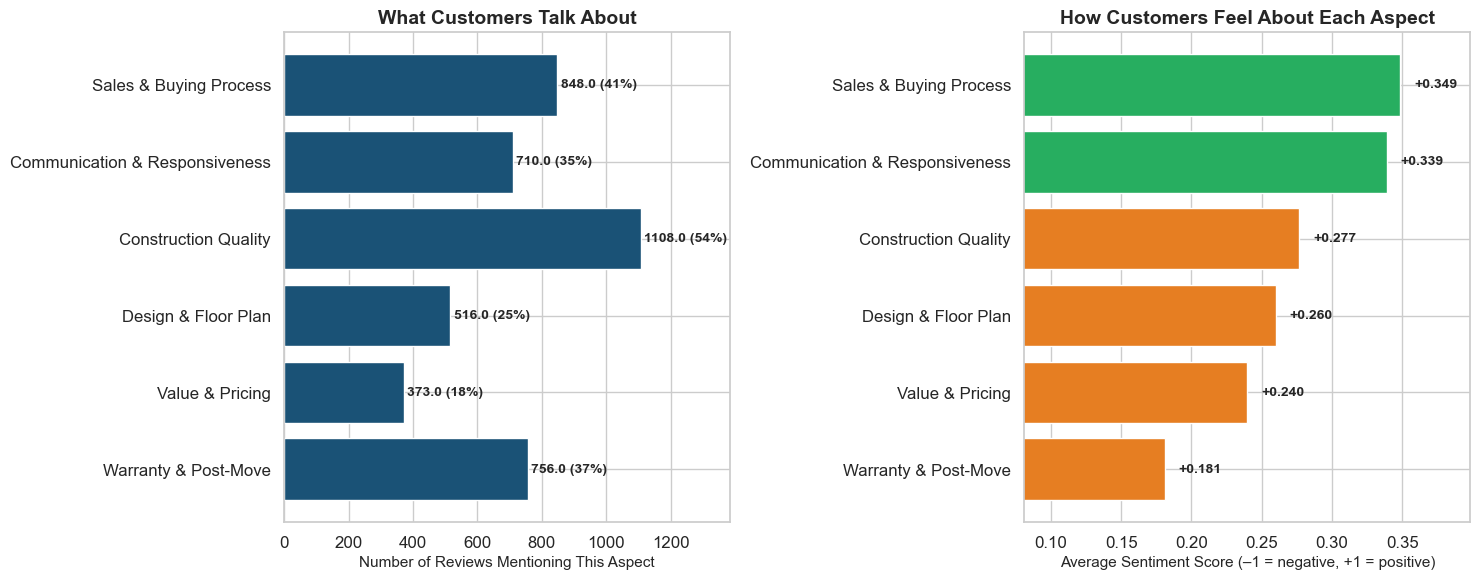

In [13]:
# visualize aspect-based results
asp_df = pd.DataFrame(aspect_results).T.sort_values("avg_sentiment")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# left: how often each aspect is mentioned
axes[0].barh(asp_df.index, asp_df["mentions"], color=SHEA_BLUE, edgecolor="white")
max_mentions = asp_df["mentions"].max()
axes[0].set_xlim(0, max_mentions * 1.25)
for i, (val, pct) in enumerate(zip(asp_df["mentions"], asp_df["pct_reviews"])):
    axes[0].text(val + 10, i, f"{val} ({pct:.0%})", va="center", fontsize=10, fontweight="bold")
axes[0].set_xlabel("Number of Reviews Mentioning This Aspect", fontsize=11)
axes[0].set_title("What Customers Talk About", fontsize=14, fontweight="bold")

# right: sentiment by aspect
colors = ["#27ae60" if v >= 0.3 else "#e67e22" if v >= 0.1 else "#c0392b" for v in asp_df["avg_sentiment"]]
axes[1].barh(asp_df.index, asp_df["avg_sentiment"], color=colors, edgecolor="white")
max_sent = asp_df["avg_sentiment"].max()
min_sent = asp_df["avg_sentiment"].min()
axes[1].set_xlim(min_sent - 0.1, max_sent + 0.05)
for i, val in enumerate(asp_df["avg_sentiment"]):
    axes[1].text(val + 0.01 if val >= 0 else val - 0.06, i, f"{val:+.3f}", va="center", fontsize=10, fontweight="bold")
axes[1].set_xlabel("Average Sentiment Score (–1 = negative, +1 = positive)", fontsize=11)
axes[1].set_title("How Customers Feel About Each Aspect", fontsize=14, fontweight="bold")
axes[1].axvline(x=0, color="black", linewidth=0.8)

plt.tight_layout()
plt.show()

weakest = asp_df["avg_sentiment"].idxmin()
strongest = asp_df["avg_sentiment"].idxmax()

Construction quality is the most frequently discussed topic, appearing in more than half of all reviews. However, it also shows lower sentiment scores compared with other aspects, indicating that many customer concerns are tied to the physical build or post-construction issues. In contrast, sales interactions and communication receive the strongest sentiment scores, suggesting that customers generally view the front-end buying experience positively. Warranty and post-move service shows the weakest sentiment, highlighting it as an area where improvements could have a meaningful impact on overall customer satisfaction.


---
# 4.3 Employee Recognition Mining

Customers often mention Shea team members by name in their reviews. This section scans through all 2,039 reviews, looks for names, and then reads the sentences around each name to figure out whether the customer was saying something positive or negative about that person. This is useful for identifying top performers who consistently get praised, or for spotting cases where a specific team member keeps coming up in negative contexts.

In [16]:
# extract employee names from reviews using spaCy named entity recognition
nlp = spacy.load("en_core_web_sm", disable=["parser", "lemmatizer"])

# minimal exclusions: company/brand names spaCy mislabels as PERSON
NOT_PERSON = {"Shea", "Sheas", "Trilogy", "Covid", "Encanterra", "HOA"}

all_employee_mentions = []
for doc, (idx, row) in zip(
    nlp.pipe(df["review_text"].astype(str).tolist(), batch_size=200),
    df.iterrows(),
):
    for ent in doc.ents:
        if ent.label_ != "PERSON":
            continue
        # use first name only to group mentions consistently
        first = ent.text.split()[0]
        first = re.sub(r"[^A-Za-z]", "", first)
        if first in NOT_PERSON or len(first) < 3 or not first[0].isupper():
            continue
        # sentiment from context window around the entity
        start = max(0, ent.start - 5)
        end = min(len(doc), ent.end + 5)
        ctx = doc[start:end].text
        all_employee_mentions.append({
            "name": first,
            "sentiment": sia.polarity_scores(ctx)["compound"],
            "total_score": row["total_score"],
            "location": row["location"],
            "state": row["state"],
        })

emp_df = pd.DataFrame(all_employee_mentions)

# aggregate by employee name
emp_summary = emp_df.groupby("name").agg(
    mentions=("sentiment", "count"),
    avg_sentiment=("sentiment", "mean"),
    avg_stars=("total_score", "mean"),
    top_location=("location", lambda x: x.mode().iloc[0] if len(x) > 0 else "Unknown"),
).sort_values("mentions", ascending=False)

# filter to employees mentioned 10+ times (likely real staff, not noise)
emp_top = emp_summary[emp_summary["mentions"] >= 10].head(20)

print("=" * 75)
print("TOP EMPLOYEE MENTIONS")
print("=" * 75)
print(f"{'Name':<15} {'Mentions':<10} {'Avg Sentiment':<16} {'Avg Stars':<12} {'Primary Location'}")
print("-" * 75)
for name, row in emp_top.iterrows():
    print(f"{name:<15} {row['mentions']:<10.0f} {row['avg_sentiment']:>+.3f}           {row['avg_stars']:<12.1f} {row['top_location']}")

TOP EMPLOYEE MENTIONS
Name            Mentions   Avg Sentiment    Avg Stars    Primary Location
---------------------------------------------------------------------------
Mike            32         +0.230           4.4          Las Vegas, NV
Ryan            27         +0.405           4.3          Rio Verde, AZ
Josh            20         +0.166           4.2          Manvel, TX
Matt            17         +0.337           4.7          Conroe, TX
Richard         16         +0.355           4.7          Indio, CA
Dan             14         +0.298           4.6          OCALA, FL
James           12         +0.366           5.0          Peoria, AZ
Jason           11         +0.378           4.1          Rio Verde, AZ
Kara            11         +0.338           4.4          Rio Verde, AZ
Steve           11         +0.161           4.5          Rio Verde, AZ
Brad            10         +0.193           4.6          Denver, NC
Laura           10         +0.222           4.6          Rio Verde,

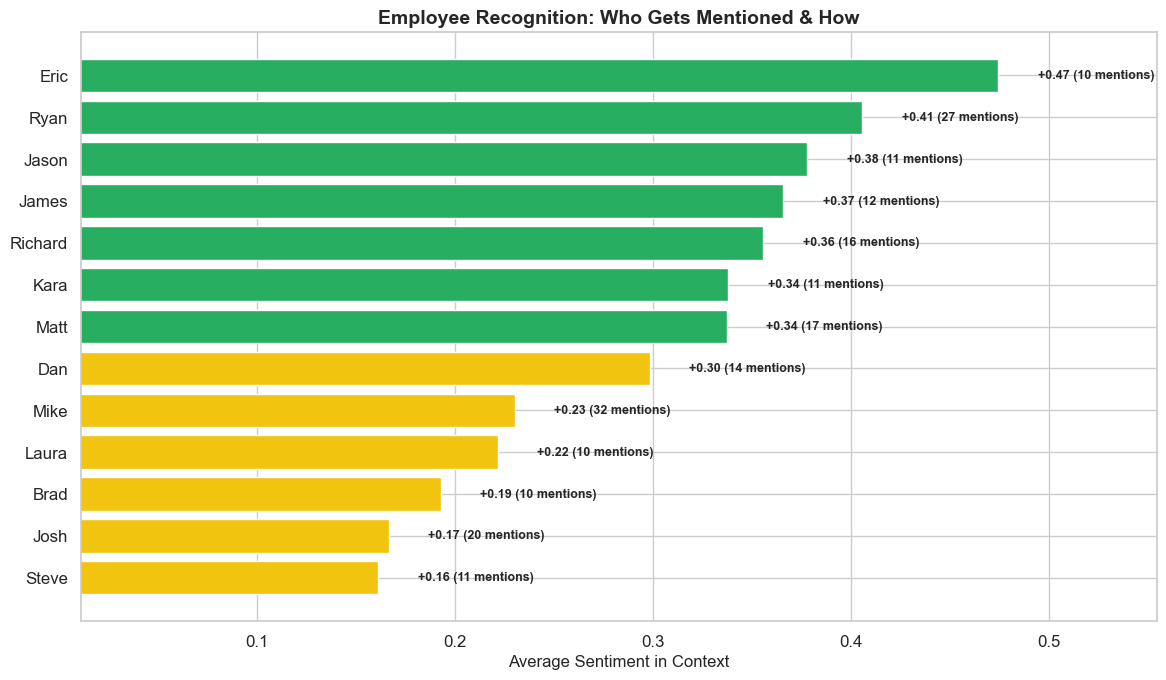

In [17]:
# visualize top 15 employees
emp_plot = emp_top.head(15).sort_values("avg_sentiment")

fig, ax = plt.subplots(figsize=(12, 7))
colors = ["#27ae60" if v >= 0.3 else "#f1c40f" if v >= 0 else "#c0392b" for v in emp_plot["avg_sentiment"]]
bars = ax.barh(emp_plot.index, emp_plot["avg_sentiment"], color=colors, edgecolor="white")
max_sent = emp_plot["avg_sentiment"].max()
min_sent = emp_plot["avg_sentiment"].min()

# add padding to axis
ax.set_xlim(min_sent - 0.15, max_sent + 0.08)

for bar, (name, row) in zip(bars, emp_plot.iterrows()):
    ax.text(bar.get_width() + 0.02 if bar.get_width() >= 0 else bar.get_width() - 0.08,
            bar.get_y() + bar.get_height()/2,
            f"{row['avg_sentiment']:+.2f} ({row['mentions']:.0f} mentions)",
            va="center", fontsize=9, fontweight="bold")

ax.set_xlabel("Average Sentiment in Context", fontsize=12)
ax.set_title("Employee Recognition: Who Gets Mentioned & How", fontsize=14, fontweight="bold")
ax.axvline(x=0, color="black", linewidth=0.8)

plt.tight_layout()
plt.show()

Mike in Las Vegas, Ryan in Indio, and Josh in Manvel are the most frequently mentioned employees, and all of them carry positive sentiment scores. That means when customers mention these people, they are saying good things. This kind of data could feed directly into recognition programs or performance reviews. It could also flag cases where a specific person keeps showing up in negative reviews, which would be an early signal for coaching or support.


---
# 4.4 Common Phrases Analysis (N-grams)

Earlier analysis looked at individual words, but meaning often comes from combinations of words. For example, the phrase “not responsive” carries the opposite meaning of the single word “responsive,” even though the word itself is positive.

This section analyzes common two-word and three-word phrases that appear frequently in positive and negative reviews. Looking at phrases instead of individual words provides a clearer picture of what customers are actually describing in their experiences.

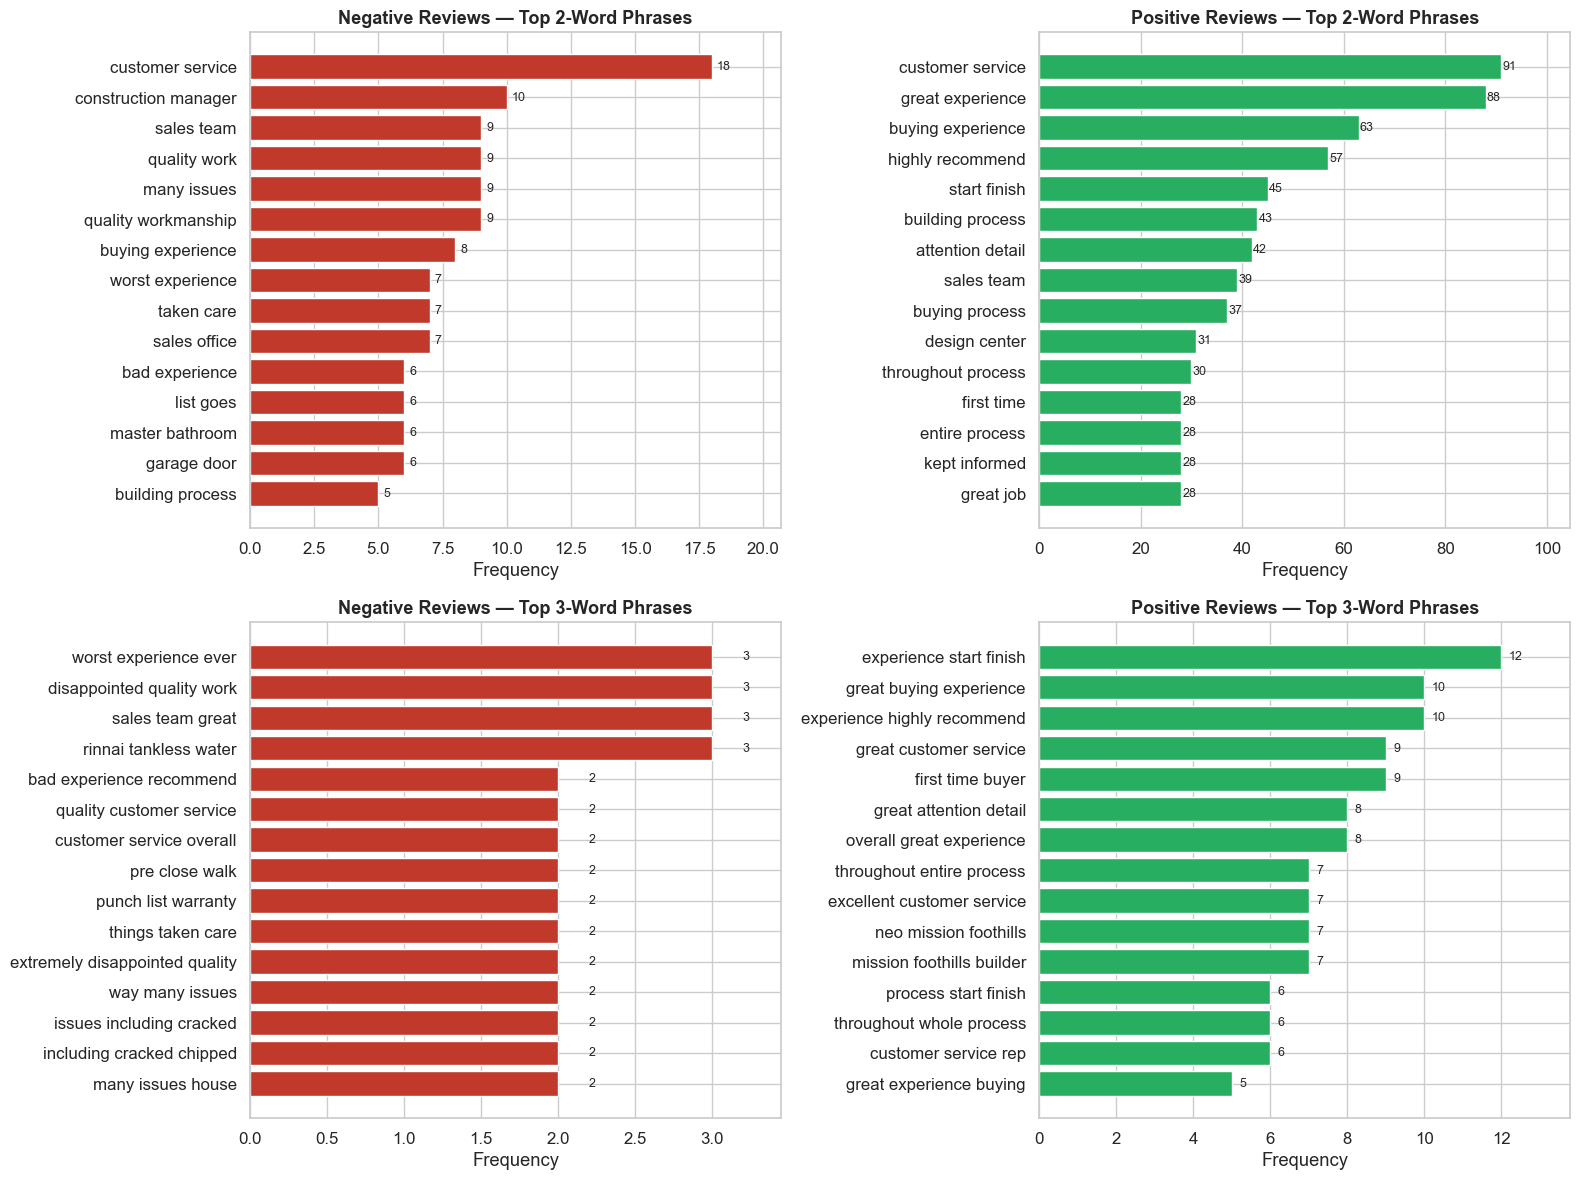

In [20]:
def get_ngrams(texts, n=2, top_k=20):
    """Extract the most common n-word phrases from a collection of texts."""
    all_text = " ".join(texts.astype(str)).lower()
    words = re.findall(r"[a-z']+", all_text)
    words = [w for w in words if w not in stop_words and len(w) > 2]
    ngrams = [" ".join(words[i:i+n]) for i in range(len(words) - n + 1)]
    return Counter(ngrams).most_common(top_k)

neg_texts = df[df["total_score"] <= 2]["review_text"]
pos_texts = df[df["total_score"] == 5]["review_text"]

neg_bigrams = get_ngrams(neg_texts, n=2, top_k=15)
pos_bigrams = get_ngrams(pos_texts, n=2, top_k=15)
neg_trigrams = get_ngrams(neg_texts, n=3, top_k=15)
pos_trigrams = get_ngrams(pos_texts, n=3, top_k=15)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

def plot_ngrams(ax, ngrams, color, title):
    phrases, counts = zip(*ngrams[::-1])
    ax.barh(phrases, counts, color=color, edgecolor="white")
    ax.set_xlim(0, max(counts) * 1.15)
    for i, val in enumerate(counts):
        ax.text(val + 0.2, i, str(val), va="center", fontsize=9)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Frequency")

plot_ngrams(axes[0, 0], neg_bigrams, "#c0392b", "Negative Reviews — Top 2-Word Phrases")
plot_ngrams(axes[0, 1], pos_bigrams, "#27ae60", "Positive Reviews — Top 2-Word Phrases")
plot_ngrams(axes[1, 0], neg_trigrams, "#c0392b", "Negative Reviews — Top 3-Word Phrases")
plot_ngrams(axes[1, 1], pos_trigrams, "#27ae60", "Positive Reviews — Top 3-Word Phrases")

plt.tight_layout()
plt.show()

The negative phrases highlight specific operational pain points. Terms related to customer service, build quality, and warranty support appear frequently in lower-rated reviews, indicating that dissatisfaction often centers around post-purchase issues or construction defects.

In contrast, the most common positive phrases focus on the sales team, the buying experience, and the overall building process. Phrases like “great experience,” “customer service,” and “start to finish” appear frequently in 5-star reviews, suggesting that customers are especially satisfied when the entire homebuying journey feels smooth and well managed from beginning to end.